# Exploratory Data Analysis: Mufulira Administrative Wards and Demographics

## 1. Introduction

This notebook performs Exploratory Data Analysis (EDA), data quality assessment, and preprocessing of the Mufulira Administrative Wards and Demographics dataset.

The dataset was extracted from the Mufulira Municipal Council Integrated Development Plan (IDP) as part of the Mufulira Municipal Council data mining project.

The purpose of this EDA is to:

- understand the structure and content of the dataset;
- identify missing, unspecified, duplicated, inconsistent, or suspicious values;
- assess the suitability of the extracted data for subsequent analysis;
- apply appropriate data cleaning and preprocessing where justified; and
- document the decisions made during the cleaning process.

The source dataset is pipe-delimited (`|`) as required by the project.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
file_path = "db-unza26-csc4792-mufulira_administrative_wards_demographics.csv"

df = pd.read_csv(file_path, sep="|")

df.head()

,Constituency,Ward_Name,Number_of_Households,Total_Population,Male_Population,Female_Population,Poverty_Level_Status
0,Unspecified,Mufulira District,30065,200182,Unspecified,Unspecified,Unspecified
1,Unspecified,Kankoyo Constituency,8193,38835,Unspecified,Unspecified,Unspecified
2,Kankoyo,John Kampengele,1126,5396,Unspecified,Unspecified,Unspecified
3,Kankoyo,Buntungwa,787,4816,Unspecified,Unspecified,Unspecified
4,Kankoyo,Kangwa Nsuluka,249,4934,Unspecified,Unspecified,Unspecified


## 2. Initial Dataset Inspection

The first stage of the EDA is to establish the basic structure of the extracted dataset before any cleaning is performed.

The inspection covers:

- number of records and variables;
- column names;
- data types;
- initial sample records; and
- general data completeness.

In [29]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 15
Number of columns: 7

Column names:
['Constituency', 'Ward_Name', 'Number_of_Households', 'Total_Population', 'Male_Population', 'Female_Population', 'Poverty_Level_Status']

Data types:
Constituency              str
Ward_Name                 str
Number_of_Households    int64
Total_Population        int64
Male_Population           str
Female_Population         str
Poverty_Level_Status      str
dtype: object


### 2.1 Full Dataset Inspection

Because this is a small dataset containing only 15 records, all records are inspected rather than relying only on a sample.

In [30]:
df

,Constituency,Ward_Name,Number_of_Households,Total_Population,Male_Population,Female_Population,Poverty_Level_Status
0,Unspecified,Mufulira District,30065,200182,Unspecified,Unspecified,Unspecified
1,Unspecified,Kankoyo Constituency,8193,38835,Unspecified,Unspecified,Unspecified
2,Kankoyo,John Kampengele,1126,5396,Unspecified,Unspecified,Unspecified
3,Kankoyo,Buntungwa,787,4816,Unspecified,Unspecified,Unspecified
4,Kankoyo,Kangwa Nsuluka,249,4934,Unspecified,Unspecified,Unspecified
5,Kankoyo,Luansobe,1333,5643,Unspecified,Unspecified,Unspecified
6,Kankoyo,Butondo,1324,3179,Unspecified,Unspecified,Unspecified
7,Kankoyo,Kwacha,860,3871,Unspecified,Unspecified,Unspecified
8,Kankoyo,Fibusa,1029,5353,Unspecified,Unspecified,Unspecified
9,Kankoyo,Mpelembe,1485,5643,Unspecified,Unspecified,Unspecified


## 3. Missing and Unspecified Values

Missing-value analysis is performed before any cleaning or transformation.

In this dataset, the extracted records do not contain Python/CSV missing values (`NaN`). However, several fields contain the literal value `"Unspecified"`. This is treated separately from `NaN` because `"Unspecified"` is an actual value stored in the source dataset.

The analysis therefore examines both:

1. conventional missing values (`NaN`); and
2. `"Unspecified"` values representing unavailable or unspecified information.

In [31]:
# Count conventional missing values
missing_values = df.isna().sum()

print("Missing values (NaN) by column:")
print(missing_values)

Missing values (NaN) by column:
Constituency            0
Ward_Name               0
Number_of_Households    0
Total_Population        0
Male_Population         0
Female_Population       0
Poverty_Level_Status    0
dtype: int64


In [32]:
# Count literal "Unspecified" values by column
unspecified_counts = (df == "Unspecified").sum()

print('Literal "Unspecified" values by column:')
print(unspecified_counts)

Literal "Unspecified" values by column:
Constituency             3
Ward_Name                0
Number_of_Households     0
Total_Population         0
Male_Population         15
Female_Population       15
Poverty_Level_Status    15
dtype: int64


## 4. Duplicate Records

Duplicate records can distort analysis by causing the same administrative record to be counted more than once.

Because this is a small dataset, every record is checked for exact duplication.

In [33]:
duplicate_count = df.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 0


## 5. Data-Type and Numerical Consistency

The demographic fields are expected to represent numerical quantities. Therefore, their data types are examined to determine whether numerical columns were extracted consistently.

In particular, `Number_of_Households`, `Total_Population`, `Male_Population`, and `Female_Population` are expected to represent counts.

The extracted dataset contains `"Unspecified"` values in the male and female population fields. These fields therefore cannot currently be treated as numerical measurements without introducing unsupported values.

In [34]:
numeric_columns = [
    "Number_of_Households",
    "Total_Population",
    "Male_Population",
    "Female_Population"
]

print(df[numeric_columns].dtypes)

Number_of_Households    int64
Total_Population        int64
Male_Population           str
Female_Population         str
dtype: object


## 6. Numerical Range Validation

The household and population fields are checked for invalid negative values.

Negative household or population counts would be logically invalid and would indicate an extraction or data-quality problem.

In [35]:
print("Negative household values:")
print(df[df["Number_of_Households"] < 0])

print("\nNegative population values:")
print(df[df["Total_Population"] < 0])

Negative household values:
Empty DataFrame
Columns: [Constituency, Ward_Name, Number_of_Households, Total_Population, Male_Population, Female_Population, Poverty_Level_Status]
Index: []

Negative population values:
Empty DataFrame
Columns: [Constituency, Ward_Name, Number_of_Households, Total_Population, Male_Population, Female_Population, Poverty_Level_Status]
Index: []


## 7. Administrative-Level Structure

The dataset contains records representing different administrative levels.

The `Ward_Name` field includes:

- a district-level record (`Mufulira District`);
- constituency-level records (`Kankoyo Constituency` and `Kantanshi Constituency`); and
- ward-level records such as `John Kampengele`, `Buntungwa`, `Minambe`, and `Bwafwano`.

These records should not automatically be treated as identical types of administrative units during analysis.

In [36]:
print(df["Ward_Name"].to_string(index=False))

     Mufulira District
  Kankoyo Constituency
       John Kampengele
             Buntungwa
        Kangwa Nsuluka
              Luansobe
               Butondo
                Kwacha
                Fibusa
              Mpelembe
Kantanshi Constituency
               Minambe
               Murundu
            Maina Soko
              Bwafwano


## 8. Data Cleaning and Preprocessing

The cleaning stage is based on the findings from the initial EDA.

Because this is a small dataset, records are retained rather than removed solely because some attributes are unavailable.

The following preprocessing decisions are applied:

1. Preserve the original extracted data in `df`.
2. Remove unnecessary leading/trailing whitespace from text fields.
3. Standardize literal `"Unspecified"` values as missing/unknown values for analysis where appropriate.
4. Convert demographic count fields to suitable numeric types where the data supports such conversion.
5. Preserve records for which the source does not provide male population, female population, or poverty-level information.
6. Create derived information only where it can be determined directly from existing fields, without inventing unsupported values.

In [37]:
df_cleaned = df.copy()

# Standardize whitespace in text columns
text_columns = df_cleaned.select_dtypes(include=["str", "object"]).columns

for column in text_columns:
    df_cleaned[column] = df_cleaned[column].str.strip()

# Treat the literal "Unspecified" as missing for analysis
df_cleaned = df_cleaned.replace("Unspecified", pd.NA)

# Ensure count columns are numeric
count_columns = ["Number_of_Households", "Total_Population"]

for column in count_columns:
    df_cleaned[column] = pd.to_numeric(
        df_cleaned[column],
        errors="coerce"
    )

df_cleaned.head()

,Constituency,Ward_Name,Number_of_Households,Total_Population,Male_Population,Female_Population,Poverty_Level_Status
0,NaN,Mufulira District,30065,200182,NaN,NaN,NaN
1,NaN,Kankoyo Constituency,8193,38835,NaN,NaN,NaN
2,Kankoyo,John Kampengele,1126,5396,NaN,NaN,NaN
3,Kankoyo,Buntungwa,787,4816,NaN,NaN,NaN
4,Kankoyo,Kangwa Nsuluka,249,4934,NaN,NaN,NaN


### 8.1 Verification After Cleaning

The cleaned dataset is inspected to verify that:

- text whitespace has been standardized;
- `"Unspecified"` values are represented consistently as missing/unknown values;
- household and population counts are numeric; and
- no records were removed during preprocessing.

In [38]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)

print("\nCleaned data types:")
print(df_cleaned.dtypes)

print("\nMissing values after preprocessing:")
print(df_cleaned.isna().sum())

print("\nCleaned dataset:")
print(df_cleaned.to_string(index=False))

Original shape: (15, 7)
Cleaned shape: (15, 7)

Cleaned data types:
Constituency              str
Ward_Name                 str
Number_of_Households    int64
Total_Population        int64
Male_Population           str
Female_Population         str
Poverty_Level_Status      str
dtype: object

Missing values after preprocessing:
Constituency             3
Ward_Name                0
Number_of_Households     0
Total_Population         0
Male_Population         15
Female_Population       15
Poverty_Level_Status    15
dtype: int64

Cleaned dataset:
Constituency              Ward_Name  Number_of_Households  Total_Population Male_Population Female_Population Poverty_Level_Status
         NaN      Mufulira District                 30065            200182             NaN               NaN                  NaN
         NaN   Kankoyo Constituency                  8193             38835             NaN               NaN                  NaN
     Kankoyo        John Kampengele                  1126 

## 9. Administrative-Level Classification

The extracted dataset contains records at different administrative levels:

- District level: `Mufulira District`
- Constituency level: `Kankoyo Constituency` and `Kantanshi Constituency`
- Ward level: individual wards belonging to Kankoyo and Kantanshi

Because these levels represent different scopes, they should not be combined indiscriminately in population or household calculations.

A derived `Administrative_Level` field is therefore created to distinguish the records while preserving the original extracted fields.

In [39]:
def classify_administrative_level(ward_name):
    if ward_name == "Mufulira District":
        return "District"
    elif ward_name.endswith("Constituency"):
        return "Constituency"
    else:
        return "Ward"

df_cleaned["Administrative_Level"] = df_cleaned["Ward_Name"].apply(
    classify_administrative_level
)

df_cleaned[["Ward_Name", "Administrative_Level"]]

,Ward_Name,Administrative_Level
0,Mufulira District,District
1,Kankoyo Constituency,Constituency
2,John Kampengele,Ward
3,Buntungwa,Ward
4,Kangwa Nsuluka,Ward
5,Luansobe,Ward
6,Butondo,Ward
7,Kwacha,Ward
8,Fibusa,Ward
9,Mpelembe,Ward


### 10.1 Records by Administrative Level

The number of records at each administrative level is examined to understand the structure of the dataset.

In [40]:
level_counts = df_cleaned["Administrative_Level"].value_counts()

print(level_counts)

Administrative_Level
Ward            12
Constituency     2
District         1
Name: count, dtype: int64


## 11. Descriptive Statistics

Descriptive statistics are calculated for the numerical fields available in the dataset.

The analysis focuses on `Number_of_Households` and `Total_Population`, because these are the demographic measures that contain actual numerical values in the extracted data.

In [41]:
numeric_columns = [
    "Number_of_Households",
    "Total_Population"
]

df_cleaned[numeric_columns].describe()

,Number_of_Households,Total_Population
count,15.000000,15.000000
mean,4036.066667,23631.000000
std,7759.217445,51144.435335
min,249.000000,3179.000000
25%,823.500000,4590.000000
50%,1126.000000,5353.000000
75%,1503.000000,6522.000000
max,30065.000000,200182.000000


## 12. Ward-Level Demographic Analysis

Ward-level analysis is performed separately because the ward records represent comparable administrative units.

The district-level and constituency-level summary records are excluded from ward-level comparisons to avoid mixing different administrative scopes.

In [42]:
ward_df = df_cleaned[
    df_cleaned["Administrative_Level"] == "Ward"
].copy()

print("Number of ward records:", len(ward_df))

ward_df[
    [
        "Constituency",
        "Ward_Name",
        "Number_of_Households",
        "Total_Population"
    ]
]

Number of ward records: 12


,Constituency,Ward_Name,Number_of_Households,Total_Population
2,Kankoyo,John Kampengele,1126,5396
3,Kankoyo,Buntungwa,787,4816
4,Kankoyo,Kangwa Nsuluka,249,4934
5,Kankoyo,Luansobe,1333,5643
6,Kankoyo,Butondo,1324,3179
7,Kankoyo,Kwacha,860,3871
8,Kankoyo,Fibusa,1029,5353
9,Kankoyo,Mpelembe,1485,5643
11,Kantanshi,Minambe,712,5198
12,Kantanshi,Murundu,1521,7401


### 13.1 Estimated Population per Household

An estimated population-per-household measure is derived by dividing total population by the number of households.

This is a derived measure rather than an originally extracted field. It is calculated only for records where both source values are available and the number of households is greater than zero.

In [43]:
ward_df["Estimated_Persons_Per_Household"] = (
    ward_df["Total_Population"] /
    ward_df["Number_of_Households"]
)

ward_df[
    [
        "Ward_Name",
        "Number_of_Households",
        "Total_Population",
        "Estimated_Persons_Per_Household"
    ]
].sort_values(
    "Estimated_Persons_Per_Household",
    ascending=False
)

,Ward_Name,Number_of_Households,Total_Population,Estimated_Persons_Per_Household
4,Kangwa Nsuluka,249,4934,19.815261
11,Minambe,712,5198,7.300562
3,Buntungwa,787,4816,6.119441
14,Bwafwano,761,4364,5.734560
8,Fibusa,1029,5353,5.202138
12,Murundu,1521,7401,4.865878
2,John Kampengele,1126,5396,4.792185
7,Kwacha,860,3871,4.501163
5,Luansobe,1333,5643,4.233308
13,Maina Soko,979,3922,4.006129


### 14.1 Ward Population Comparison

Ward populations are compared to identify differences in the number of people represented by each ward.

In [44]:
ward_population = ward_df.sort_values(
    "Total_Population",
    ascending=False
)

ward_population[
    ["Ward_Name", "Total_Population"]
]

,Ward_Name,Total_Population
12,Murundu,7401
5,Luansobe,5643
9,Mpelembe,5643
2,John Kampengele,5396
8,Fibusa,5353
11,Minambe,5198
4,Kangwa Nsuluka,4934
3,Buntungwa,4816
14,Bwafwano,4364
13,Maina Soko,3922


### 14.2 Population by Ward

A bar chart is used to visually compare the total population across the individual wards.

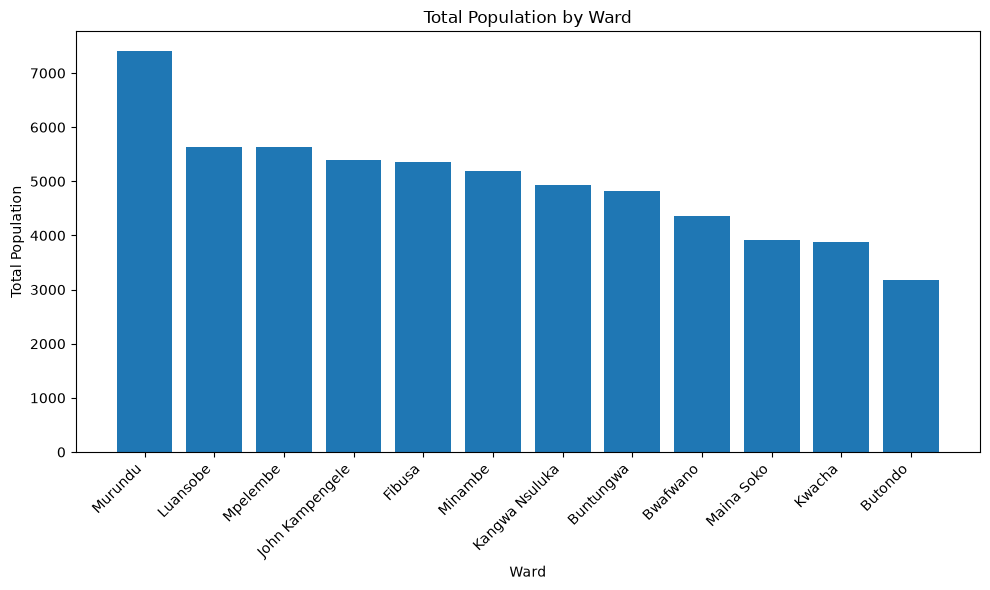

In [45]:
plt.figure(figsize=(10, 6))

plt.bar(
    ward_population["Ward_Name"],
    ward_population["Total_Population"]
)

plt.title("Total Population by Ward")
plt.xlabel("Ward")
plt.ylabel("Total Population")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 14.3 Households by Ward

The number of households is compared across wards to identify differences in household distribution.

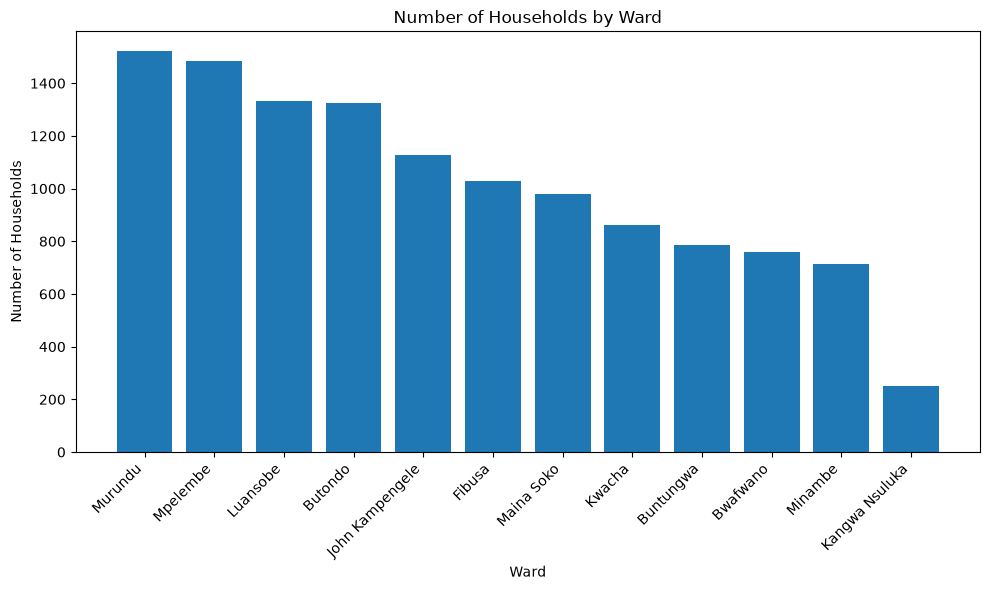

In [46]:
ward_households = ward_df.sort_values(
    "Number_of_Households",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    ward_households["Ward_Name"],
    ward_households["Number_of_Households"]
)

plt.title("Number of Households by Ward")
plt.xlabel("Ward")
plt.ylabel("Number of Households")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 15. Constituency-Level Summary

The dataset contains two constituency-level records. These records are examined separately from the ward-level records because they represent larger administrative areas.

In [47]:
constituency_df = df_cleaned[
    df_cleaned["Administrative_Level"] == "Constituency"
].copy()

constituency_df[
    [
        "Ward_Name",
        "Number_of_Households",
        "Total_Population"
    ]
]

,Ward_Name,Number_of_Households,Total_Population
1,Kankoyo Constituency,8193,38835
10,Kantanshi Constituency,10117,55728


## 16. Final Data Quality Check

A final validation is performed after preprocessing to ensure that:

- no source records were removed;
- the household and population fields remain numeric;
- administrative-level classification has been added consistently; and
- unavailable demographic variables remain explicitly unknown rather than being assigned unsupported values.

In [48]:
print("Original record count:", len(df))
print("Cleaned record count:", len(df_cleaned))

print("\nCleaned data types:")
print(df_cleaned.dtypes)

print("\nAdministrative levels:")
print(df_cleaned["Administrative_Level"].value_counts())

print("\nRemaining missing values:")
print(df_cleaned.isna().sum())

Original record count: 15
Cleaned record count: 15

Cleaned data types:
Constituency              str
Ward_Name                 str
Number_of_Households    int64
Total_Population        int64
Male_Population           str
Female_Population         str
Poverty_Level_Status      str
Administrative_Level      str
dtype: object

Administrative levels:
Administrative_Level
Ward            12
Constituency     2
District         1
Name: count, dtype: int64

Remaining missing values:
Constituency             3
Ward_Name                0
Number_of_Households     0
Total_Population         0
Male_Population         15
Female_Population       15
Poverty_Level_Status    15
Administrative_Level     0
dtype: int64


## 17. EDA Findings

The exploratory analysis identified the following characteristics of the Mufulira Administrative Wards and Demographics dataset:

- The dataset contains 15 records and 7 original variables.
- No exact duplicate records were identified.
- No conventional `NaN` values were present in the extracted dataset.
- The fields `Male_Population`, `Female_Population`, and `Poverty_Level_Status` contain the literal value `"Unspecified"` for all records.
- `Constituency` also contains `"Unspecified"` for the district-level and constituency summary records where a more specific constituency value was not provided.
- `Number_of_Households` and `Total_Population` were successfully represented as numerical variables.
- The `Ward_Name` field contains records at different administrative levels, including a district-level record, constituency-level records, and individual ward-level records.
- Because these administrative levels represent different scopes, district and constituency summary records were not treated as individual wards during ward-level comparisons.
- No negative household or population values were identified.

## 18. Cleaning and Preprocessing Summary

The following preprocessing actions were applied:

1. A copy of the original extracted dataframe was created as `df_cleaned`, preserving the original `df` for reference.
2. Leading and trailing whitespace in text fields was standardized.
3. Literal `"Unspecified"` values were converted to missing (`pd.NA`) in the cleaned analytical dataframe so that unavailable information is represented consistently as unknown.
4. Household and total population counts were explicitly converted to numeric values.
5. No source records were deleted.
6. No unsupported values were invented for male population, female population, or poverty-level status.
7. A derived `Administrative_Level` variable was added to distinguish district, constituency, and ward records.
8. A derived `Estimated_Persons_Per_Household` measure was calculated for comparable ward-level records using the available household and population counts.

These decisions preserve the information extracted from the source while preventing unsupported assumptions from being introduced during preprocessing.

## 19. Conclusion

The dataset provides administrative, household, and total population information for selected areas within Mufulira Municipal Council.

The EDA showed that the dataset is small and contains no exact duplicate records or conventional missing values. However, several demographic attributes remain unspecified in the extracted source data, particularly male population, female population, and poverty-level status.

The preprocessing therefore focused on preserving all available records, standardizing the representation of unavailable information, validating numerical fields, and distinguishing administrative levels. No unsupported demographic values were introduced.

The resulting `df_cleaned` dataframe is suitable for further analysis while retaining transparency about limitations in the extracted data.

In [49]:
# Final overview of the cleaned analytical dataset
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Constituency          12 non-null     str  
 1   Ward_Name             15 non-null     str  
 2   Number_of_Households  15 non-null     int64
 3   Total_Population      15 non-null     int64
 4   Male_Population       0 non-null      str  
 5   Female_Population     0 non-null      str  
 6   Poverty_Level_Status  0 non-null      str  
 7   Administrative_Level  15 non-null     str  
dtypes: int64(2), str(6)
memory usage: 1.1 KB


In [50]:
# Preview of the cleaned dataset
df_cleaned.head(15)

,Constituency,Ward_Name,Number_of_Households,Total_Population,Male_Population,Female_Population,Poverty_Level_Status,Administrative_Level
0,NaN,Mufulira District,30065,200182,NaN,NaN,NaN,District
1,NaN,Kankoyo Constituency,8193,38835,NaN,NaN,NaN,Constituency
2,Kankoyo,John Kampengele,1126,5396,NaN,NaN,NaN,Ward
3,Kankoyo,Buntungwa,787,4816,NaN,NaN,NaN,Ward
4,Kankoyo,Kangwa Nsuluka,249,4934,NaN,NaN,NaN,Ward
5,Kankoyo,Luansobe,1333,5643,NaN,NaN,NaN,Ward
6,Kankoyo,Butondo,1324,3179,NaN,NaN,NaN,Ward
7,Kankoyo,Kwacha,860,3871,NaN,NaN,NaN,Ward
8,Kankoyo,Fibusa,1029,5353,NaN,NaN,NaN,Ward
9,Kankoyo,Mpelembe,1485,5643,NaN,NaN,NaN,Ward
